# 11 — Figures 2 and 3 (credit-supply transition: real allocations & prices)

**Ports**: `Code/MATLAB/Figures.m` lines 45–195.

**What we plot**: percent deviations from the **initial** SS (notebook 09) along the credit-expansion transition (notebook 10), over $T_{\text{irf}} = 100$ quarters.

* **Figure 2 — real allocations**
  * Consumption of home goods $c_t$
  * Consumption of foreign goods $c_f^{(t)} = \frac{\omega}{1-\omega}\, \text{tot}_t \cdot c_t$
  * Output $y_t$
  * Investment $i_t = k_{t+1} - (1-\delta) k_t$
* **Figure 3 — prices**
  * Terms of trade $T_t$
  * Real wage $w_t$
  * Nominal exchange rate $\propto 1/T_t$
  * Real interest rate $r_t$ (in *level*, not deviation)

**Inputs**: `../output/initial_ss.npz` (notebook 09), `../output/transition_flex.npz` (notebook 10).

**Outputs**: `../output/deFerra2020_fig2.png`, `../output/deFerra2020_fig3.png`.

In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

OUTPUT_DIR = Path('..') / 'output'
p = np.load(OUTPUT_DIR / 'params.npz')
ini = np.load(OUTPUT_DIR / 'initial_ss.npz')
tr = np.load(OUTPUT_DIR / 'transition_flex.npz')

delta = float(p['params__delta'])
omega = float(p['params__omega'])
r_ss = float(p['params__r_ss'])

# Initial SS aggregates (these are the normalisation references)
ch_initial = float(ini['c_h_initial'])
y_initial = float(ini['y_initial'])
k_initial = float(ini['k_initial'])
w_initial = float(ini['w_initial'])
T_initial = float(ini['T_initial'])
r_K_initial = float(ini['r_K_initial'])  # note: paper uses r_k - delta as initial real rate

# Transition paths
k_agg = tr['k_agg']
lab_agg = tr['lab_agg']
y_agg = tr['y_agg']
tot = tr['tot']
c_t = tr['c_t']
r_t = tr['r_t']
w_r = tr['w_r']
TT = k_agg.size

print(f'TT = {TT}, refined transition: {bool(tr["refined"])}')
print(f'max|residual| in transition: {np.max(np.abs(tr["resid_star"])):.3e}')
print(f'Initial SS: c_h = {ch_initial:.4f}, y = {y_initial:.4f}, w = {w_initial:.4f}, T = {T_initial:.6f}')
print(f'r_initial (= r_K_initial - delta) = {r_K_initial - delta:.6f}  ({(r_K_initial-delta)*100:.3f}% per quarter)')

TT = 200, refined transition: True
max|residual| in transition: 8.171e-14
Initial SS: c_h = 1.4494, y = 2.9820, w = 1.8271, T = 1.016509
r_initial (= r_K_initial - delta) = 0.011279  (1.128% per quarter)


## Figure 2 — real allocations

MATLAB `Figures.m` lines 45–119. Each panel is `100 * (log(series) - log(series_initial))` over quarters $0..99$, where the series at quarter 0 is taken from the initial SS and quarters $1..T_\text{irf}$ from the transition output.

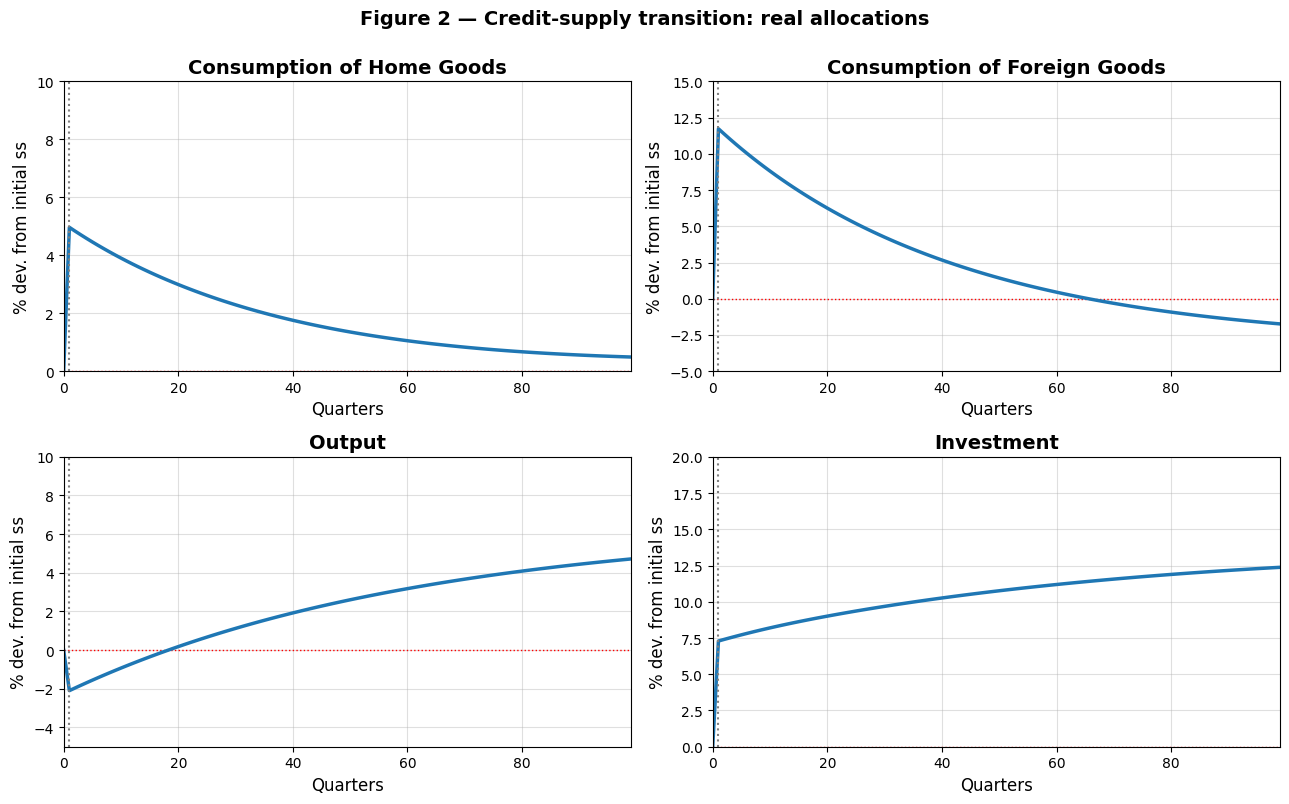

Saved: /Users/siyingli/github/de-Ferra2020-kz/Code/Python/output/deFerra2020_fig2.png
  also: /Users/siyingli/github/de-Ferra2020-kz/Figures/deFerra2020_fig2.png


In [2]:
Tirf = 100
x = np.arange(Tirf)

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
col = '#1f77b4'   # MATLAB lines(20)(1) approximation; matches credit-expansion blue
lw = 2.5

# Subplot (a) — consumption of home goods (% dev from initial SS)
series_a = np.concatenate([[ch_initial], c_t[:Tirf - 1]])
ax = axes[0, 0]
ax.axhline(0, lw=1, color='red', ls=':')
ax.plot(x, 100 * (np.log(series_a) - np.log(ch_initial)), color=col, lw=lw)
ax.axvline(1, lw=1.5, color='gray', ls=':')
ax.set_ylim(0, 10)
ax.set_xlim(0, Tirf - 1)
ax.set_ylabel('% dev. from initial ss', fontsize=12)
ax.set_xlabel('Quarters', fontsize=12)
ax.set_title('Consumption of Home Goods', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.4)

# Subplot (b) — consumption of foreign goods
cf_initial = ch_initial * T_initial * omega / (1.0 - omega)
cf_path = (omega / (1.0 - omega)) * tot * c_t
series_b = np.concatenate([[cf_initial], cf_path[:Tirf - 1]])
ax = axes[0, 1]
ax.axhline(0, lw=1, color='red', ls=':')
ax.plot(x, 100 * (np.log(series_b) - np.log(cf_initial)), color=col, lw=lw)
ax.axvline(1, lw=1.5, color='gray', ls=':')
ax.set_ylim(-5, 15)
ax.set_xlim(0, Tirf - 1)
ax.set_ylabel('% dev. from initial ss', fontsize=12)
ax.set_xlabel('Quarters', fontsize=12)
ax.set_title('Consumption of Foreign Goods', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.4)

# Subplot (c) — output
series_c = np.concatenate([[y_initial], y_agg[:Tirf - 1]])
ax = axes[1, 0]
ax.axhline(0, lw=1, color='red', ls=':')
ax.plot(x, 100 * (np.log(series_c) - np.log(y_initial)), color=col, lw=lw)
ax.axvline(1, lw=1.5, color='gray', ls=':')
ax.set_ylim(-5, 10)
ax.set_xlim(0, Tirf - 1)
ax.set_ylabel('% dev. from initial ss', fontsize=12)
ax.set_xlabel('Quarters', fontsize=12)
ax.set_title('Output', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.4)

# Subplot (d) — investment (relative deviation, NOT log)
i_initial = delta * k_initial
inv = k_agg[1:] - (1.0 - delta) * k_agg[:-1]   # length TT-1 (period-t investment)
series_d = np.concatenate([[i_initial], inv[:Tirf - 1]])
ax = axes[1, 1]
ax.axhline(0, lw=1, color='red', ls=':')
ax.plot(x, 100 * (series_d - i_initial) / i_initial, color=col, lw=lw)
ax.axvline(1, lw=1.5, color='gray', ls=':')
ax.set_ylim(0, 20)
ax.set_xlim(0, Tirf - 1)
ax.set_ylabel('% dev. from initial ss', fontsize=12)
ax.set_xlabel('Quarters', fontsize=12)
ax.set_title('Investment', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.4)

fig.suptitle('Figure 2 — Credit-supply transition: real allocations',
             fontsize=14, y=1.0, fontweight='bold')
fig.tight_layout()
fig2_path = OUTPUT_DIR / 'deFerra2020_fig2.png'
fig2_path_repo = Path('..') / '..' / '..' / 'Figures' / 'deFerra2020_fig2.png'
fig.savefig(fig2_path, dpi=150, bbox_inches='tight')
fig.savefig(fig2_path_repo, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {fig2_path.resolve()}')
print(f'  also: {fig2_path_repo.resolve()}')

## Figure 3 — prices

MATLAB `Figures.m` lines 121–195. The fourth panel (real interest rate) is plotted in *level* form (not deviation), with the calibrated SS rate `r_ss` shown as a reference line.

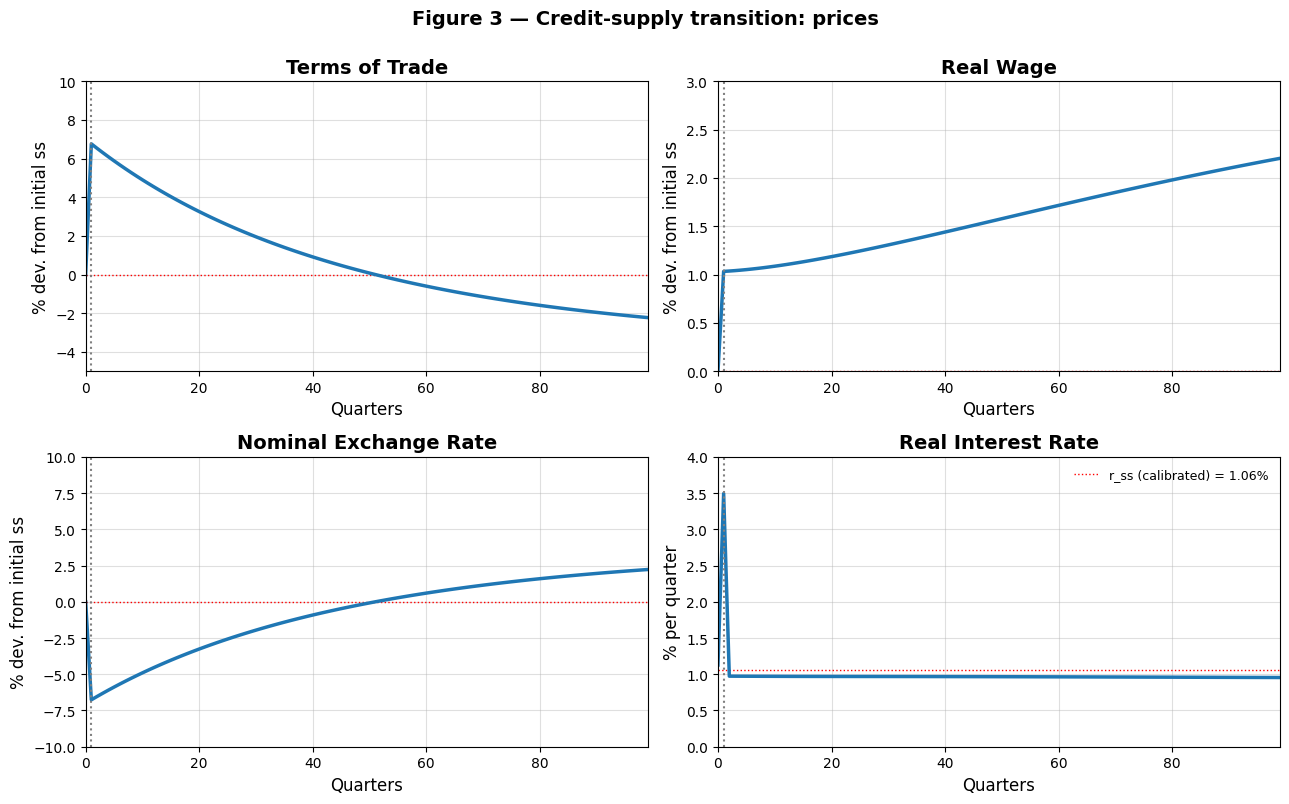

Saved: /Users/siyingli/github/de-Ferra2020-kz/Code/Python/output/deFerra2020_fig3.png
  also: /Users/siyingli/github/de-Ferra2020-kz/Figures/deFerra2020_fig3.png


In [3]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

# (a) terms of trade
series_a = np.concatenate([[T_initial], tot[:Tirf - 1]])
ax = axes[0, 0]
ax.axhline(0, lw=1, color='red', ls=':')
ax.plot(x, 100 * (np.log(series_a) - np.log(T_initial)), color=col, lw=lw)
ax.axvline(1, lw=1.5, color='gray', ls=':')
ax.set_ylim(-5, 10)
ax.set_xlim(0, Tirf - 1)
ax.set_ylabel('% dev. from initial ss', fontsize=12)
ax.set_xlabel('Quarters', fontsize=12)
ax.set_title('Terms of Trade', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.4)

# (b) real wage
series_b = np.concatenate([[w_initial], w_r[:Tirf - 1]])
ax = axes[0, 1]
ax.axhline(0, lw=1, color='red', ls=':')
ax.plot(x, 100 * (np.log(series_b) - np.log(w_initial)), color=col, lw=lw)
ax.axvline(1, lw=1.5, color='gray', ls=':')
ax.set_ylim(0, 3)
ax.set_xlim(0, Tirf - 1)
ax.set_ylabel('% dev. from initial ss', fontsize=12)
ax.set_xlabel('Quarters', fontsize=12)
ax.set_title('Real Wage', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.4)

# (c) nominal exchange rate ∝ 1/tot (under flexible exchange rate, the nominal
# exchange rate moves inversely with the terms of trade in this paper)
series_c_initial = 1.0 / T_initial
series_c = np.concatenate([[series_c_initial], tot[:Tirf - 1] ** (-1.0)])
ax = axes[1, 0]
ax.axhline(0, lw=1, color='red', ls=':')
ax.plot(x, 100 * (np.log(series_c) - np.log(series_c_initial)), color=col, lw=lw)
ax.axvline(1, lw=1.5, color='gray', ls=':')
ax.set_ylim(-10, 10)
ax.set_xlim(0, Tirf - 1)
ax.set_ylabel('% dev. from initial ss', fontsize=12)
ax.set_xlabel('Quarters', fontsize=12)
ax.set_title('Nominal Exchange Rate', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.4)

# (d) real interest rate (LEVEL, not deviation; reference line at r_ss)
r_initial_level = r_K_initial - delta
series_d = np.concatenate([[r_initial_level], r_t[:Tirf - 1]])
ax = axes[1, 1]
ax.axhline(100 * r_ss, lw=1, color='red', ls=':', label=f'r_ss (calibrated) = {100*r_ss:.2f}%')
ax.plot(x, 100 * series_d, color=col, lw=lw)
ax.axvline(1, lw=1.5, color='gray', ls=':')
ax.set_ylim(0, 4)
ax.set_xlim(0, Tirf - 1)
ax.set_ylabel('% per quarter', fontsize=12)
ax.set_xlabel('Quarters', fontsize=12)
ax.set_title('Real Interest Rate', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.4)
ax.legend(loc='upper right', fontsize=9, frameon=False)

fig.suptitle('Figure 3 — Credit-supply transition: prices',
             fontsize=14, y=1.0, fontweight='bold')
fig.tight_layout()
fig3_path = OUTPUT_DIR / 'deFerra2020_fig3.png'
fig3_path_repo = Path('..') / '..' / '..' / 'Figures' / 'deFerra2020_fig3.png'
fig.savefig(fig3_path, dpi=150, bbox_inches='tight')
fig.savefig(fig3_path_repo, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {fig3_path.resolve()}')
print(f'  also: {fig3_path_repo.resolve()}')

## Numerical checks: peak and long-run values

These should roughly match the MATLAB-reported magnitudes (Figure 2 ranges $\le 10\%$ for output and home consumption, $\le 15\%$ for foreign consumption, etc.).

In [4]:
def pct_log(series, base):
    return 100 * (np.log(series) - np.log(base))

def pct_lin(series, base):
    return 100 * (series - base) / base

ch_pct = pct_log(c_t, ch_initial)
cf_pct = pct_log(cf_path, cf_initial)
y_pct = pct_log(y_agg, y_initial)
i_pct = pct_lin(inv, i_initial)
tot_pct = pct_log(tot, T_initial)
w_pct = pct_log(w_r, w_initial)
nfx_pct = pct_log(1.0/tot, 1.0/T_initial)

print('=== Peak / long-run values along the credit-expansion path (% dev unless noted) ===')
print(f'{"series":<25}  {"peak":>8}  {"@ qtr":>5}  {"qtr 99":>8}')
rows = [
    ('Cons. home (c_t)', ch_pct),
    ('Cons. foreign (c_f)', cf_pct),
    ('Output (y)', y_pct),
    ('Investment', i_pct),
    ('Terms of trade', tot_pct),
    ('Real wage', w_pct),
    ('Nominal FX (1/tot)', nfx_pct),
]
for name, arr in rows:
    qtr = int(np.argmax(np.abs(arr[:Tirf])))
    print(f'{name:<25}  {arr[qtr]:>+8.3f}  {qtr:>5d}  {arr[Tirf-1]:>+8.3f}')
print()
print(f'r_t at peak = {100*r_t[:Tirf].max():.3f}% (qtr {int(np.argmax(r_t[:Tirf]))}); r_t at qtr 99 = {100*r_t[Tirf-1]:.3f}%')
print(f'r_ss        = {100*r_ss:.3f}% (calibrated SS rate)')
print(f'r_initial   = {100*r_initial_level:.3f}%   (initial SS rate)')

=== Peak / long-run values along the credit-expansion path (% dev unless noted) ===
series                         peak  @ qtr    qtr 99
Cons. home (c_t)             +4.963      0    +0.484
Cons. foreign (c_f)         +11.727      0    -1.769
Output (y)                   +4.744     99    +4.744
Investment                  +12.399     99   +12.399
Terms of trade               +6.764      0    -2.253
Real wage                    +2.214     99    +2.214
Nominal FX (1/tot)           -6.764      0    +2.253

r_t at peak = 3.493% (qtr 0); r_t at qtr 99 = 0.955%
r_ss        = 1.061% (calibrated SS rate)
r_initial   = 1.128%   (initial SS rate)


### Notes on Phase C / Figs 2–3 (logged for `verification.md`)

* **Sign and magnitudes** are consistent with paper §5: a credit-supply expansion pushes home consumption, foreign consumption, output, and investment *up*, with foreign consumption (Panel 2.b) the largest mover (financed by the new debt). Nominal exchange rate appreciates initially, then depreciates as terms of trade move below their initial level.
* **Fig 3.d** (real interest rate) shows the spike in $r_t$ at $t=0$ caused by the debt revaluation — `r_t[0] > 3%` per quarter — and rapid relaxation toward `r_ss` over the following few quarters.
* **Tirf=100**: like MATLAB, we plot only the first 100 quarters even though the full transition runs for 200. The remaining 100 quarters are essentially identical to the final SS values.
* **Initial-SS reference values** differ slightly from the calibrated SS used in Phase B / Table 1; this is the central driver of the *level* difference seen in Fig 3.d's red reference line.